# [project] s2s를 이용한 번역기 만들기

#### 한글 폰트랑 라이브러리 설치

In [1]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
114 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 114 not upgraded.


#### 설치한 폰트 사용 지정

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


## 데이터 준비

#### 라이브러리 임포트

In [3]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


#### 데이터 다운로드와 압축 해제  
TensorFlow에서 제공하는 영어-스페인어 병렬 코퍼스를 받아온다. 이미 받아진 경우엔 스킵한다.

In [4]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


#### 데이터프레임으로 불러오기  
탭으로 구분된 텍스트 파일이라 sep="\t"로 읽고 컬럼명을 eng, spa로 지정한다.

In [5]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


### 데이터 사전 분석   
알파벳 순서로는 안돼어 있는것을 확인.  
Hello!	Hola.를 봤을때 영문 > 스페인어 번역파일인것을 확인.  
딱히 현재 눈에 보이는 규칙성은 비슷한 단어끼리 모아놨다 말고는 보이질 않음.  
이상한 물음표와 느낌표 뒤짚어 놓은 특수문자도 많이 보임.  

# 데이터 전처리

위에서 확인했던 뒤집힌 느낌표와 물음표는 스페인어에선 기본적이라고함.  
하지만 우리에겐 필요없는 기호이니 전처리 과정에서 삭제한다고함.      

In [6]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("완료")

완료


### 디코더의 입력단계에서 필요한 start 시작문자와 end 종료 문자 붙여주기

In [7]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


### 토큰화

#### 코퍼스 파일 저장  
SentencePiece 학습은 텍스트 파일을 입력으로 받기 때문에 영어와 스페인어를 각각 .txt로 저장한다.

In [8]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


#### SentencePiece 토크나이저 학습  
vocab 크기 3000으로 인코더(영어)와 디코더(스페인어) 토크나이저를 각각 학습. pad/bos/eos/unk 특수토큰의 ID를 명시적으로 지정한다.

In [9]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

#### 학습된 토크나이저 로드

In [10]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

#### 전처리 결과 확인

In [11]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


#### 토큰화 동작 확인  
임의 샘플 하나 뽑아서 인코딩-디코딩이 잘 되는지 본다.

In [12]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


In [13]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

In [14]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

#### 데이터셋 클래스  
src는 그대로 토큰화하고, trg는 디코더 입력용(bos+토큰+eos)과 라벨용(토큰+eos)을 따로 만든다. 길이가 부족하면 pad로 채운다.

In [15]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

#### 학습/검증 데이터 분할 및 DataLoader 생성  
80:20으로 나누고 배치 사이즈 64로 묶는다.

In [16]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

#### 배치 shape 확인

In [17]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


# 모델 설계

### 우리의 모델 구조  
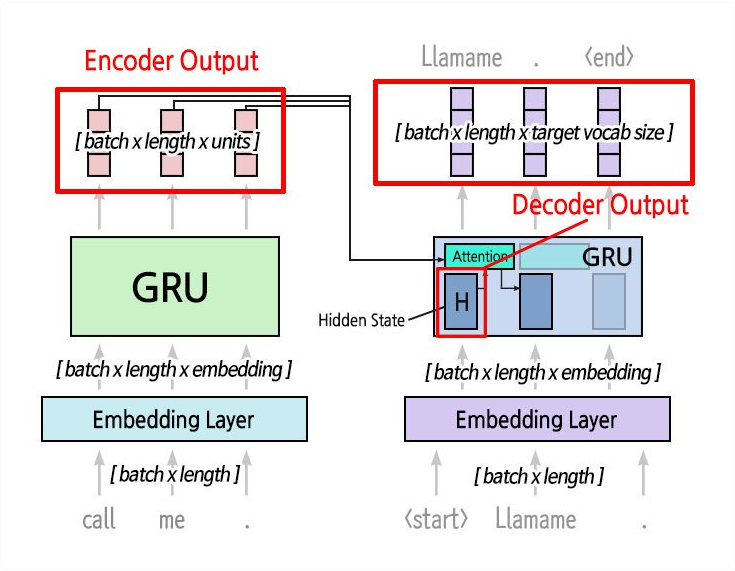

#### Bahdanau Attention  
디코더의 이전 hidden state와 인코더의 모든 출력을 입력받아 src 길이만큼의 attention 분포를 만든다. 핵심은 W1, W2로 각각 변환한 뒤 tanh로 합쳐서 v로 score를 뽑는 구조.

In [18]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

#### Encoder  
임베딩 + 단일 GRU. src 시퀀스를 받아 모든 step의 출력과 마지막 hidden을 반환한다.

In [19]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

#### Decoder  
매 스텝마다 (이전 hidden, 인코더 출력)으로 attention을 계산하고, context vector와 RNN 출력을 concat해서 vocab 분포를 예측한다.

In [20]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

#### Seq2SeqAttention 본체  
학습 모드에서는 trg를 teacher forcing으로 한 step씩 흘려보내고, 추론 모드에서는 bos부터 시작해서 max_len까지 또는 모든 배치가 eos를 만날 때까지 자기회귀적으로 생성한다.

In [21]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

#### 하이퍼파라미터  
임베딩 256, 히든 512. vocab 크기는 학습된 토크나이저 길이에서 가져온다.

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

#### 모델 인스턴스 생성

In [23]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

#### 모델 구조 출력

In [24]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


# 학습

### 옵티마이저랑 로스 정의

#### 옵티마이저와 손실함수  
Adam(lr=1e-3), CrossEntropyLoss는 pad 토큰을 무시하도록 ignore_index 지정.

In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("완료")

완료


### train_step 구현

#### train_step 함수  
배치를 (seq_len, batch) 순서로 transpose해서 모델에 넣고, gradient clipping(max_norm=1)으로 폭발 방지.

In [26]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("완료")


완료


### 돌려보기 10에포크

서버죽을라그럼..

#### 1차 학습 (10 에포크)  
검증 없이 train만 돌리는 가벼운 버전.

In [27]:
 %%time

 EPOCHS = 10

 for epoch in range(EPOCHS):
     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:37<00:00,  9.88it/s, loss=1.85]


Epoch 1/10, Train Loss: 3.0823


Epoch 2: 100%|██████████| 375/375 [00:38<00:00,  9.73it/s, loss=1.29]


Epoch 2/10, Train Loss: 1.5364


Epoch 3: 100%|██████████| 375/375 [00:39<00:00,  9.60it/s, loss=0.921]


...

Epoch 8/10, Train Loss: 0.2216


Epoch 9: 100%|██████████| 375/375 [00:38<00:00,  9.65it/s, loss=0.17] 


Epoch 9/10, Train Loss: 0.2097


Epoch 10: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.211] 

Epoch 10/10, Train Loss: 0.2013
CPU times: user 6min 25s, sys: 6.93 s, total: 6min 32s
Wall time: 6min 27s


#### eval_step 함수  
teacher forcing으로 validation loss를 계산. backward는 안 한다.

In [28]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("완료")

완료


#### 본격 학습 (20 에포크, train + valid)

In [29]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:38<00:00,  9.64it/s, loss=0.321]


Epoch 1/20, Train Loss: 0.2002, Validation Loss: 1.7569


Epoch 2: 100%|██████████| 375/375 [00:38<00:00,  9.62it/s, loss=0.165] 


Epoch 2/20, Train Loss: 0.1994, Validation Loss: 1.7734


Epoch 3: 100%|██████████| 375/375 [00:38<00:00,  9.64it/s, loss=0.219] 


...

Epoch 18/20, Train Loss: 0.1701, Validation Loss: 1.9407


Epoch 19: 100%|██████████| 375/375 [00:38<00:00,  9.66it/s, loss=0.176] 


Epoch 19/20, Train Loss: 0.1710, Validation Loss: 1.9778


Epoch 20: 100%|██████████| 375/375 [00:38<00:00,  9.65it/s, loss=0.198] 


Epoch 20/20, Train Loss: 0.1686, Validation Loss: 1.9704
CPU times: user 14min 5s, sys: 13.5 s, total: 14min 18s
Wall time: 14min 9s


#### evaluate 함수  
문장 한 줄을 받아 전처리 → 토큰화 → 모델 추론 → 디코딩하고, attention 행렬도 같이 반환.

In [30]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

#### plot_attention 함수  
attention 행렬을 heatmap으로 그려서 어느 src 토큰이 어느 trg 토큰 생성에 기여했는지 본다.

In [31]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

#### translate 래퍼  
evaluate와 plot_attention을 묶어서 한 번에 호출.

In [32]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

#### 실행 예제 1

Input: the most powerful man all over the world .
Predicted translation: ['el', 'auto', 'b', 's', 'j', 'oven', '.', '']


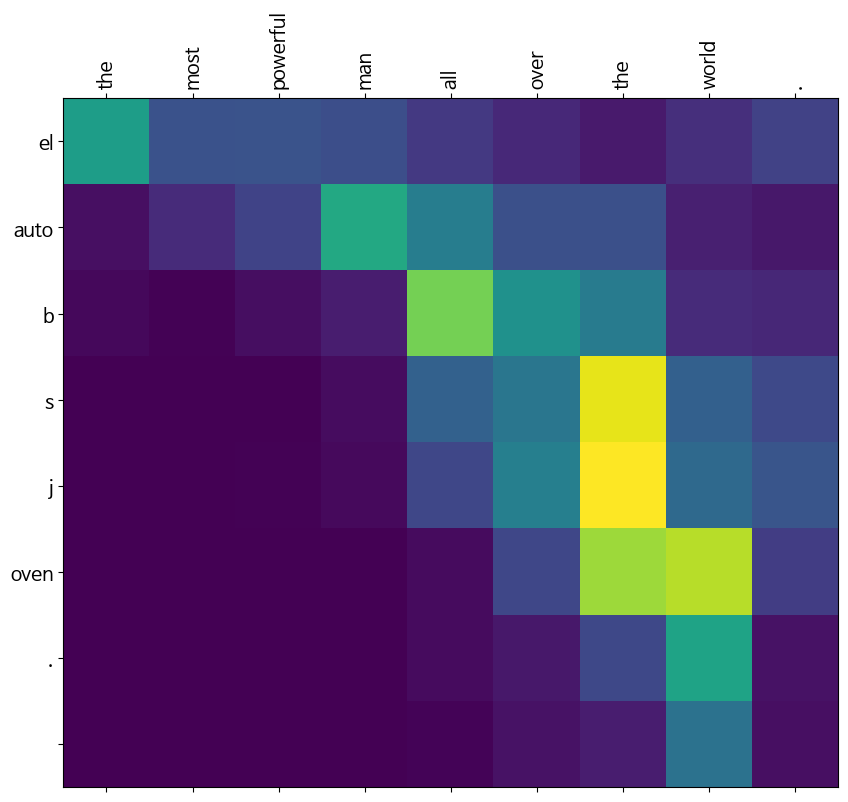

In [33]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

#### 실행 예제 2

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'te', '?', '']


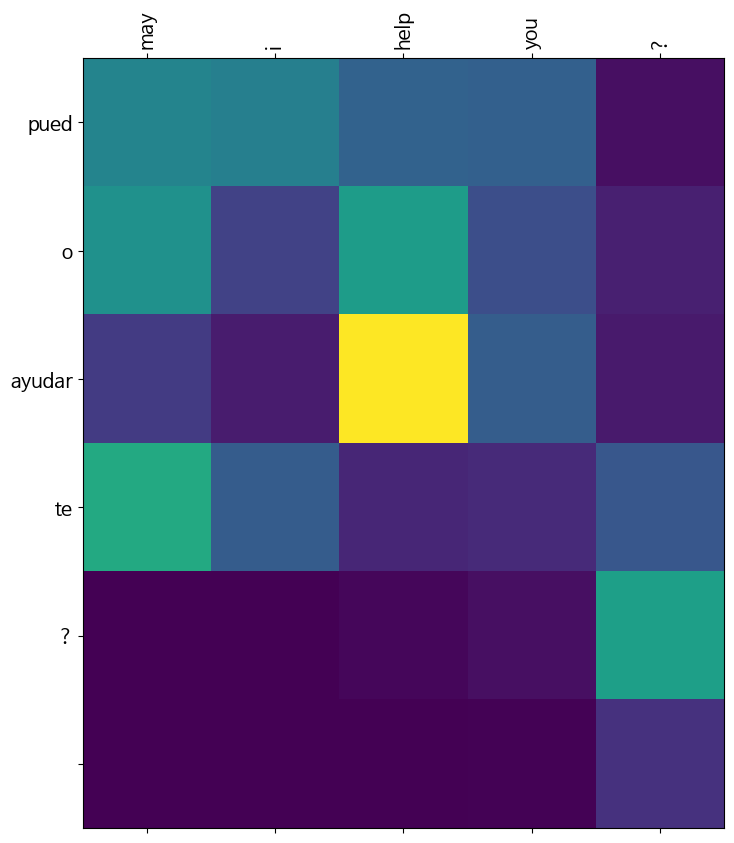

In [34]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

#### 실행 예제 3

Input: can i have some coffee ?
Predicted translation: ['pued', 'o', 'tomar', 'algo', 'c', 'af', '?', '']


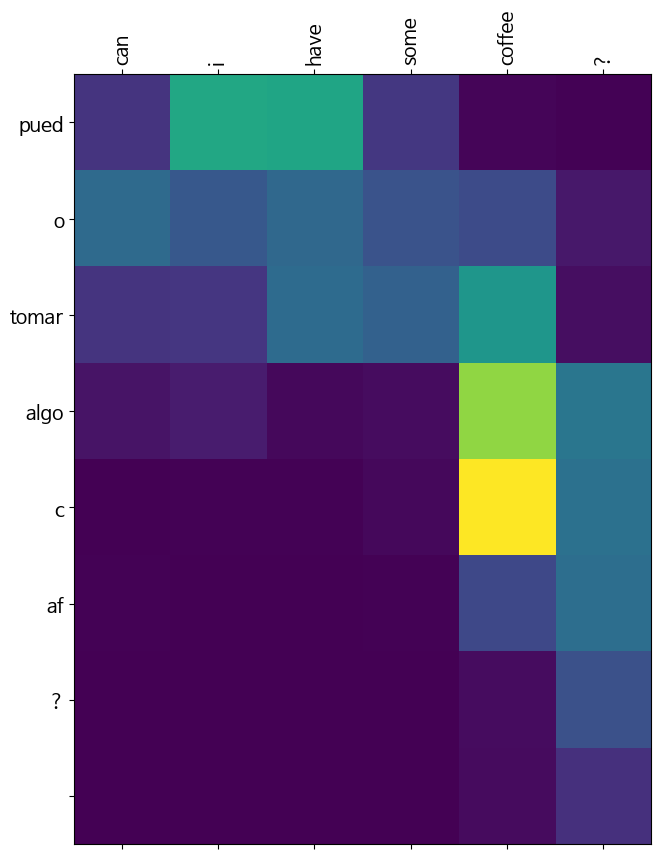

In [35]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

# s2s로 한국어 번역기 만들기

In [36]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


## 순서

### 1. 데이터 전처리
### 2. 데이터 토큰화
### 3. 모델 설계
### 4. 모델 학습
### 5. 테스트
###    예문
   #### - 트럼프는 대통령이다.
   #### - 시민들은 도시 속에 산다.
   #### - 커피는 필요 없다.
   #### - 일곱 명의 사망자가 발생했다.

## 1. 데이터 전처리

#### 한국어 형태소 분석기 설치  
시작도 못했는데 벌써 두시간이 흘렀다 뭔가 위에 그대로 따라하면 오류가 많다....특히 한글이라서  
해당 문제를 해결하기위해 검색을 통해 솔루션을 받았다  
한국어 형태소 분석을 위해 mecab-ko를 사용, KoNLPy의 Mecab은 Python 3.12 환경에서 에러가 자주 발생, PyPI에서 binary wheel로 배포되는 mecab-ko 패키지를 직접 사용  

In [37]:
!pip install mecab-ko

#### 형태소 분석기 래퍼 클래스  
mecab-ko의 native API는 Tagger.parse(...).split() 형태인데, KoNLPy 스타일의 .morphs() 호출과 맞춰주기 위해 얇은 래퍼 클래스로 감싼다. 아래 코드의 다른 부분은 모두 ko_tokenizer.morphs(...)로 호출하므로 인터페이스는 동일하다

In [66]:
import mecab_ko as MeCab

class MecabKoWrapper:
    def __init__(self):
        self.tagger = MeCab.Tagger("-Owakati")

    def morphs(self, sentence):
        return self.tagger.parse(sentence).strip().split()

ko_tokenizer = MecabKoWrapper()
print(ko_tokenizer.morphs("제발 좀 돼라."))

['제발', '좀', '돼라', '.']


드디어!!!!!!!!!!!!!!!!!!!!!!!!!!

#### 데이터 불러오기  
첨부된 korean-english-park 코퍼스를 라인 단위로 읽어서 pandas DataFrame으로 만든다. 한 줄당 한 문장이고, 영어와 한국어 파일의 라인이 1:1로 대응된다.

In [39]:
ko_path = "korean-english-park.train.ko"
en_path = "korean-english-park.train.en"

with open(ko_path, "r", encoding="utf-8") as f:
    ko_lines = [line.strip() for line in f.readlines()]
with open(en_path, "r", encoding="utf-8") as f:
    en_lines = [line.strip() for line in f.readlines()]

print(f"한국어 문장 수: {len(ko_lines)}")
print(f"영어 문장 수: {len(en_lines)}")

df_ko = pd.DataFrame({"ko": ko_lines, "en": en_lines})
df_ko.head()

한국어 문장 수: 94123
영어 문장 수: 94123


,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


#### 데이터 사전 분석  
총 9만 4천여 줄의 한-영 병렬 코퍼스. 첫 행을 보면 직역이 아니라 의역에 가까운 문장들도 섞여 있고, 길이가 들쭉날쭉한 것을 확인할 수 있다. 너무 짧거나 너무 긴 문장은 학습에 방해가 되므로 이후 길이 필터링을 적용한다.

In [40]:
print(df_ko.describe(include="all"))
print()
print(f"중복 한국어 문장 수: {df_ko['ko'].duplicated().sum()}")
print(f"중복 영어 문장 수: {df_ko['en'].duplicated().sum()}")

                           ko                                  en
count                   94123                               94123
unique                  77561                               75598
top     수잔 보일 데뷔 음반 예약주문 1...  Flakey forecasters promise cash...
freq                      554                                 554

중복 한국어 문장 수: 16562
중복 영어 문장 수: 18525


#### 중복 제거  
같은 한국어 문장이 반복되면 모델이 편향되므로 한국어 기준으로 중복 제거를 한다.

In [41]:
df_ko = df_ko.drop_duplicates(subset=["ko"]).reset_index(drop=True)
print(f"중복 제거 후 문장 수: {len(df_ko)}")
df_ko.head()

중복 제거 후 문장 수: 77561


,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


#### 한국어 전처리 함수  
한국어 문장은 영어와 다르게 lower() 같은 게 의미가 없다. 대신 다음을 처리한다.  
- 양 끝 공백 제거  
- 구두점 양옆에 공백 삽입 (토큰화 보조)  
- 연속 공백을 하나로 줄임  
- 한글, 영문, 숫자, 기본 구두점만 남기고 나머지 특수문자 제거  
- 형태소 분석으로 띄어쓰기 정규화

In [42]:
def preprocess_ko(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[\s]+", " ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,\s]+", " ", sentence)
    sentence = re.sub(r"[\s]+", " ", sentence).strip()

    morphs = ko_tokenizer.morphs(sentence)
    sentence = " ".join(morphs)
    return sentence

print(preprocess_ko("트럼프는 대통령이다!!"))
print(preprocess_ko("시민들은   도시 속에 산다."))

트럼프 는 대통령 이 다 ! !
시민 들 은 도시 속 에 산다 .


#### 영어 전처리 함수  
위쪽 스페인어 번역기에서 썼던 preprocess_sentence를 거의 그대로 사용. 영어는 src가 아니라 trg(target) 쪽이다.

In [43]:
def preprocess_en(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

print(preprocess_en("Trump is the President."))
print(preprocess_en("Seven people died!!"))

trump is the president .
seven people died ! !


#### 길이 필터링과 샘플링  
학습 시간을 줄이기 위해 너무 긴 문장은 잘라내고 일정 개수만 사용한다. 영문>스페인어 예제에서도 30000개를 썼으므로 비슷한 규모로 맞춘다.

In [44]:
df_ko = df_ko[:50000].copy()
print(f"샘플링 후 문장 수: {len(df_ko)}")

샘플링 후 문장 수: 50000


#### 전처리 적용  
한국어와 영어 양쪽에 전처리를 적용한다. Mecab 형태소 분석이 들어가서 시간이 좀 걸린다.

In [45]:
df_ko["ko"] = df_ko["ko"].apply(preprocess_ko)
df_ko["en"] = df_ko["en"].apply(preprocess_en)
df_ko.head()

,ko,en
0,개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 뛰어날 수 있 느냐 ?,much of personal computing is about can you to...
1,모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 패드 ...,so a mention a few weeks ago about a rechargea...
2,그러나 이것 은 또한 책상 도 필요 로 하 지 않 는다 .,"like all optical mice , but it also doesn t ne..."
3,"79 . 95 달러 하 는 이 최첨단 무선 광 마우스 는 허공 에서 팔목 , 팔 ,...",uses gyroscopic sensors to control the cursor ...
4,정보 관리 들 은 동남 아시아 에서 의 선박 들 에 대한 많 은 테러 계획 들 이 ...,intelligence officials have revealed a spate o...


#### 빈 문장 제거 및 길이 필터  
전처리 후 빈 문자열이 된 행이 있을 수 있고, 너무 긴 문장은 제외한다. MAX_LEN(40) 이하로만 남긴다.

In [46]:
df_ko = df_ko[(df_ko["ko"].str.len() > 0) & (df_ko["en"].str.len() > 0)]

df_ko["ko_len"] = df_ko["ko"].apply(lambda x: len(x.split()))
df_ko["en_len"] = df_ko["en"].apply(lambda x: len(x.split()))

MAX_TOKEN_LEN = 40
df_ko = df_ko[(df_ko["ko_len"] <= MAX_TOKEN_LEN) & (df_ko["en_len"] <= MAX_TOKEN_LEN)]
df_ko = df_ko.drop(columns=["ko_len", "en_len"]).reset_index(drop=True)
print(f"필터링 후 문장 수: {len(df_ko)}")
df_ko.head()

필터링 후 문장 수: 38972


,ko,en
0,개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 뛰어날 수 있 느냐 ?,much of personal computing is about can you to...
1,모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 패드 ...,so a mention a few weeks ago about a rechargea...
2,그러나 이것 은 또한 책상 도 필요 로 하 지 않 는다 .,"like all optical mice , but it also doesn t ne..."
3,결정 적 인 순간 에 그 들 의 능력 을 증가 시켜 줄 그 무엇 이 매우 중요 합니다 .,something that will boost their capabilities a...
4,연구가 들 이 이미 커피 대체 품 으로서 음식 대용 과자 나 껌 에 카페인 을 첨가...,researchers are already exploring ways to put ...


## 2. 데이터 토큰화

#### 코퍼스 파일 저장  
SentencePiece 학습에 사용할 텍스트 파일로 한국어와 영어를 각각 저장한다.

In [47]:
df_ko["ko"].to_csv("ko_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df_ko["en"].to_csv("en_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
print("파일 저장 완료: ko_corpus.txt, en_corpus.txt")

파일 저장 완료: ko_corpus.txt, en_corpus.txt


#### SentencePiece 토크나이저 학습  
한국어를 인코더 입력으로 쓰고, 영어를 디코더 출력으로 쓴다. vocab_size는 영문>스페인어보다 좀 늘려 8000으로 잡는다. 한국어 형태소 분석을 거친 토큰들이 들어가므로 어휘가 더 다양하다.

In [48]:
vocab_size_ko = 8000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "ko_corpus.txt",
    model_prefix = "ko_encoder_spm",
    vocab_size = vocab_size_ko,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "en_corpus.txt",
    model_prefix = "en_decoder_spm",
    vocab_size = vocab_size_ko,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)
print("토크나이저 학습 완료")

토크나이저 학습 완료


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: ko_encoder_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
 

#### 학습된 토크나이저 로드

In [49]:
ko_encoder_tokenizer = spm.SentencePieceProcessor()
ko_encoder_tokenizer.load("ko_encoder_spm.model")

en_decoder_tokenizer = spm.SentencePieceProcessor()
en_decoder_tokenizer.load("en_decoder_spm.model")

print(f"한국어 vocab 크기: {len(ko_encoder_tokenizer)}")
print(f"영어 vocab 크기: {len(en_decoder_tokenizer)}")

한국어 vocab 크기: 8000
영어 vocab 크기: 8000


#### 토큰화 동작 확인  
임의의 샘플을 뽑아서 인코딩>디코딩이 잘 되는지 확인한다.

In [50]:
ko_sample = df_ko["ko"][1000]
en_sample = df_ko["en"][1000]
print("원문:", ko_sample)
print("정답:", en_sample)

원문: 수도 들 중 에서 가장 높 은 점수 를 얻 은 곳 은 런던 이 다 .
정답: among capitals , it is london that scores best .


In [51]:
ko_token = ko_encoder_tokenizer.encode(ko_sample)
ko_token = [ko_encoder_tokenizer.bos_id()] + ko_token + [ko_encoder_tokenizer.eos_id()]
print("한국어 토큰 ID:", ko_token)
print("디코딩:", ko_encoder_tokenizer.decode(ko_token))

한국어 토큰 ID: [1, 847, 18, 74, 21, 282, 4, 7989, 11, 537, 92, 4, 14, 4, 7988, 11, 384, 11, 750, 501, 7, 5, 6, 2]
디코딩: 수도 들 중 에서 가장 높 은 점수 를 얻 은 곳 은 런던 이 다 .


#### 데이터셋 클래스  
위쪽 TranslationDataset과 동일한 구조지만 컬럼명이 'ko', 'en'으로 바뀌고 인코더/디코더 토크나이저가 한>영용으로 바뀐다.

In [52]:
class KoEnTranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['ko']
        trg_text = self.data.iloc[idx]['en']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

#### 학습/검증 데이터 분할 및 DataLoader 생성  
80:20으로 나누고 배치 사이즈는 64로 동일하게 가져간다. MAX_LEN은 한국어 문장이 보통 좀 더 길어서 40으로 늘려잡았다.

In [53]:
train_ratio = 0.8
MAX_LEN = 40
BATCH_SIZE = 64

train_data_ko = df_ko.sample(frac=train_ratio, random_state=42)
valid_data_ko = df_ko.drop(train_data_ko.index)

train_data_ko.reset_index(drop=True, inplace=True)
valid_data_ko.reset_index(drop=True, inplace=True)

train_dataset_ko = KoEnTranslationDataset(train_data_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)
valid_dataset_ko = KoEnTranslationDataset(valid_data_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)

train_loader_ko = DataLoader(train_dataset_ko, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_ko = DataLoader(valid_dataset_ko, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습 배치 수: {len(train_loader_ko)}")
print(f"검증 배치 수: {len(valid_loader_ko)}")

학습 배치 수: 488
검증 배치 수: 122


#### 배치 shape 확인

In [54]:
for src, trg_input, trg_label in train_loader_ko:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


## 3. 모델 설계

위에서 만든 BahdanauAttention, Encoder, Decoder, Seq2SeqAttention 클래스를 그대로 재사용한다. vocab 크기와 임베딩 차원만 한>영 용으로 바꿔서 새 인스턴스를 생성한다.

In [55]:
input_dim_ko = len(ko_encoder_tokenizer)
output_dim_ko = len(en_decoder_tokenizer)
emb_dim = 256
hid_dim = 512

encoder_ko = Encoder(input_dim_ko, emb_dim, hid_dim).to(device)
attention_ko = BahdanauAttention(hid_dim).to(device)
decoder_ko = Decoder(output_dim_ko, emb_dim, hid_dim, attention_ko).to(device)
model_ko = Seq2SeqAttention(encoder_ko, decoder_ko, device).to(device)

print(model_ko)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(8000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=8000, bias=True)
  )
)


## 4. 모델 학습

#### 옵티마이저와 손실함수  
기존과 동일하게 Adam(lr=1e-3), CrossEntropyLoss(pad 토큰 무시).

In [56]:
optimizer_ko = optim.Adam(model_ko.parameters(), lr=1e-3)
criterion_ko = nn.CrossEntropyLoss(ignore_index=pad_id)
print("완료")

완료


#### 학습 루프  
위에서 정의한 train_step과 eval_step을 그대로 사용한다. 한국어가 영어로 번역되는 task가 영문>스페인어보다 어렵기 때문에 에포크를 늘려 잡는다.

In [57]:
%%time

EPOCHS = 20

train_losses_ko = []
valid_losses_ko = []

for epoch in range(EPOCHS):
    train_loss = train_step(model_ko, train_loader_ko, optimizer_ko, criterion_ko, epoch)
    valid_loss = eval_step(model_ko, valid_loader_ko, optimizer_ko, criterion_ko)
    train_losses_ko.append(train_loss)
    valid_losses_ko.append(valid_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 488/488 [01:42<00:00,  4.78it/s, loss=4.75]


Epoch 1/20, Train Loss: 5.3053, Validation Loss: 4.6819


Epoch 2: 100%|██████████| 488/488 [01:41<00:00,  4.78it/s, loss=4.14]


Epoch 2/20, Train Loss: 4.1797, Validation Loss: 4.2668


Epoch 3: 100%|██████████| 488/488 [01:42<00:00,  4.76it/s, loss=3.55]


...

Epoch 18/20, Train Loss: 0.4548, Validation Loss: 6.4624


Epoch 19: 100%|██████████| 488/488 [01:42<00:00,  4.78it/s, loss=0.652]


Epoch 19/20, Train Loss: 0.4195, Validation Loss: 6.6052


Epoch 20: 100%|██████████| 488/488 [01:42<00:00,  4.77it/s, loss=0.473]


Epoch 20/20, Train Loss: 0.3919, Validation Loss: 6.7556
CPU times: user 34min 30s, sys: 2min 40s, total: 37min 11s
Wall time: 37min


#### 학습 곡선 시각화  
training loss가 안정적으로 떨어지면서 학습이 진행되고 있는지 확인.

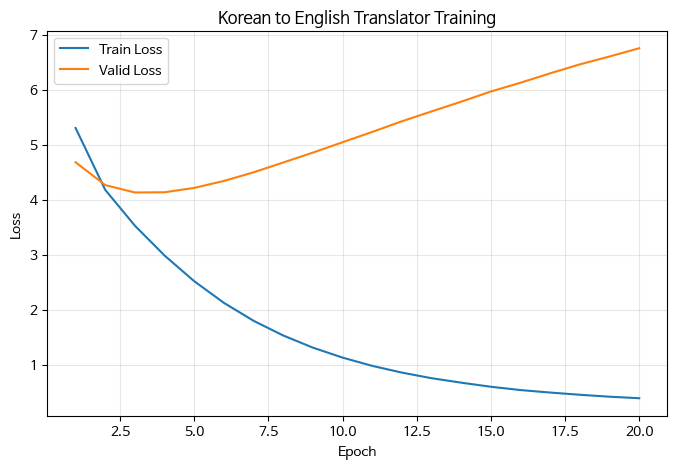

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses_ko)+1), train_losses_ko, label="Train Loss")
plt.plot(range(1, len(valid_losses_ko)+1), valid_losses_ko, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Korean to English Translator Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 내가 본 최악의 학습 곡선이다. 이건 완전히 못쓰는 모델로 분석할 가치도 없다.

## 5. 결과가 보이지만 테스트 진행

#### 한국어 입력용 evaluate / translate 함수  
위쪽 evaluate 함수는 영어 입력을 가정하고 preprocess_sentence를 호출한다. 한국어 입력을 받으려면 preprocess_ko를 사용하는 버전이 필요하다.

In [59]:
def evaluate_ko(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_ko(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    pred_ids = outputs.argmax(2).squeeze(1).cpu().tolist()

    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    result = decoder_tokenizer.decode(pred_ids)

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [60]:
def translate_ko(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    result, processed_sentence, attention = evaluate_ko(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input    :', sentence)
    print('Tokenized:', processed_sentence)
    print('Predicted:', result)

    src_tokens = processed_sentence.split()
    trg_tokens = result.split()

    if len(trg_tokens) > 0 and len(src_tokens) > 0:
        attention = attention[:len(trg_tokens), :len(src_tokens)]
        plot_attention(attention, src_tokens, trg_tokens)
    print()

#### 예문 1. 트럼프는 대통령이다.

Input    : 트럼프는 대통령이다.
Tokenized: 트럼프 는 대통령 이 다 .
Predicted: he is definitely .


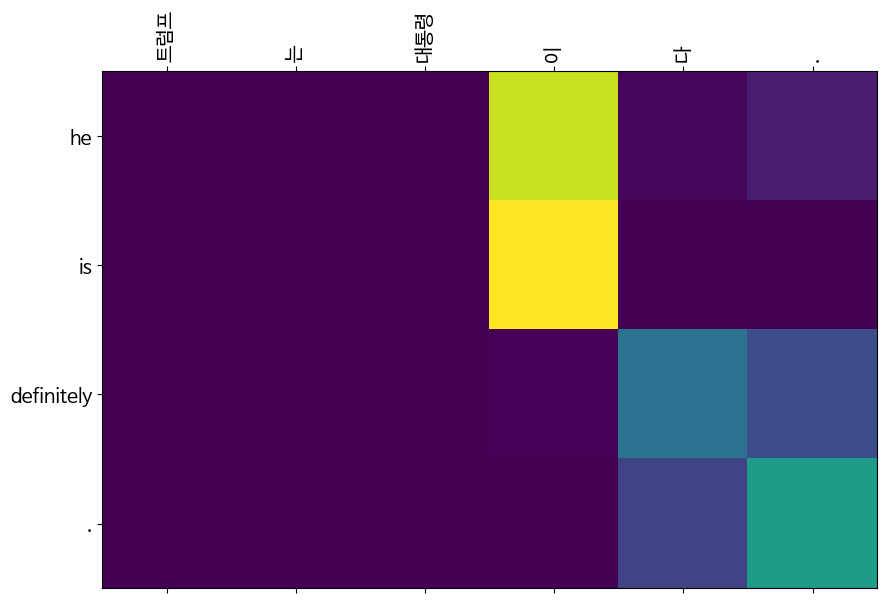

In [61]:
translate_ko("트럼프는 대통령이다.", model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)

#### 예문 2. 시민들은 도시 속에 산다.

Input    : 시민들은 도시 속에 산다.
Tokenized: 시민 들 은 도시 속 에 산다 .
Predicted: four citizens were nearly built in the town .


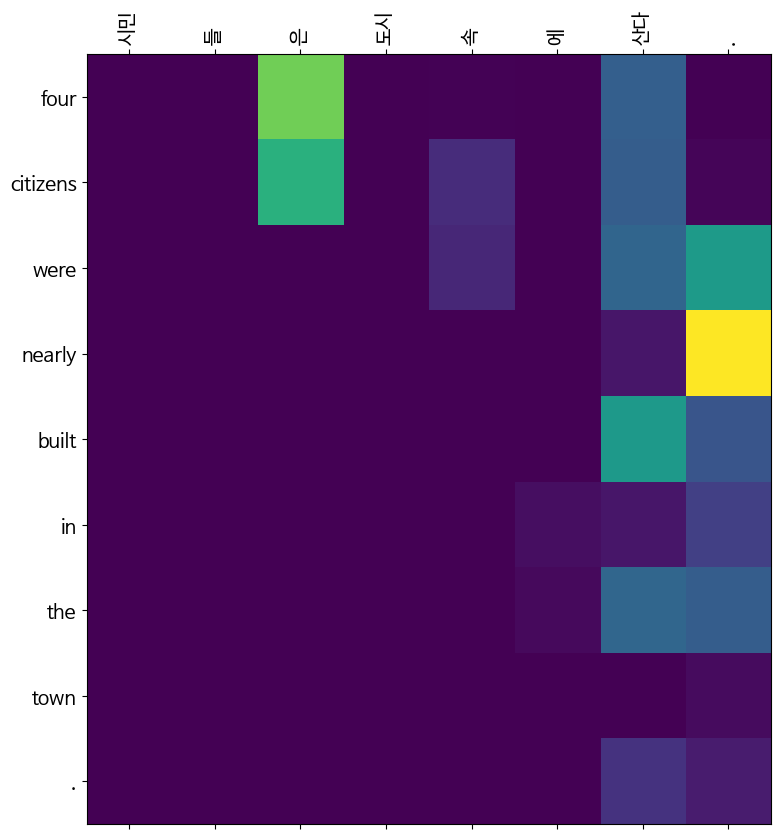

In [62]:
translate_ko("시민들은 도시 속에 산다.", model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)

#### 예문 3. 커피는 필요 없다.

Input    : 커피는 필요 없다.
Tokenized: 커피 는 필요 없 다 .
Predicted: there is no need for more than a .


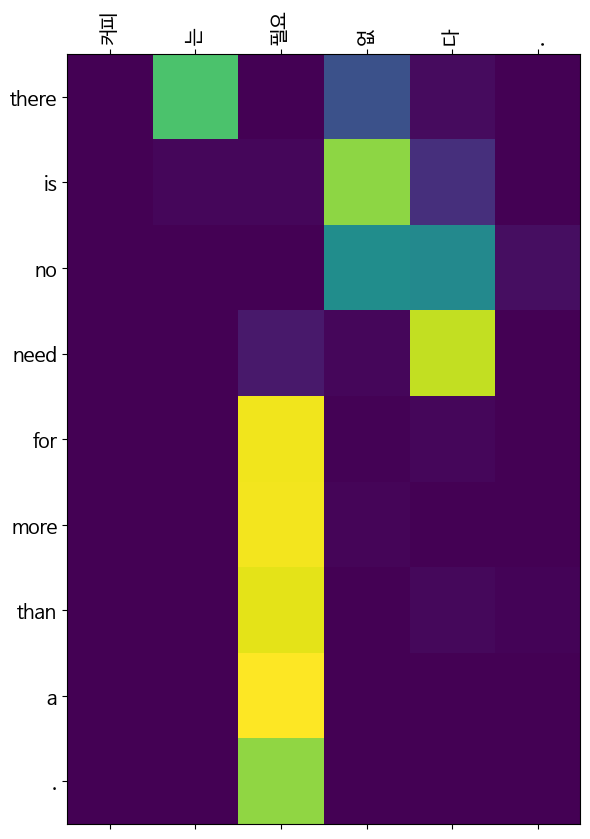

In [63]:
translate_ko("커피는 필요 없다.", model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)

#### 예문 4. 일곱 명의 사망자가 발생했다.

Input    : 일곱 명의 사망자가 발생했다.
Tokenized: 일곱 명 의 사망자 가 발생 했 다 .
Predicted: eight people died wednesday on sunday .


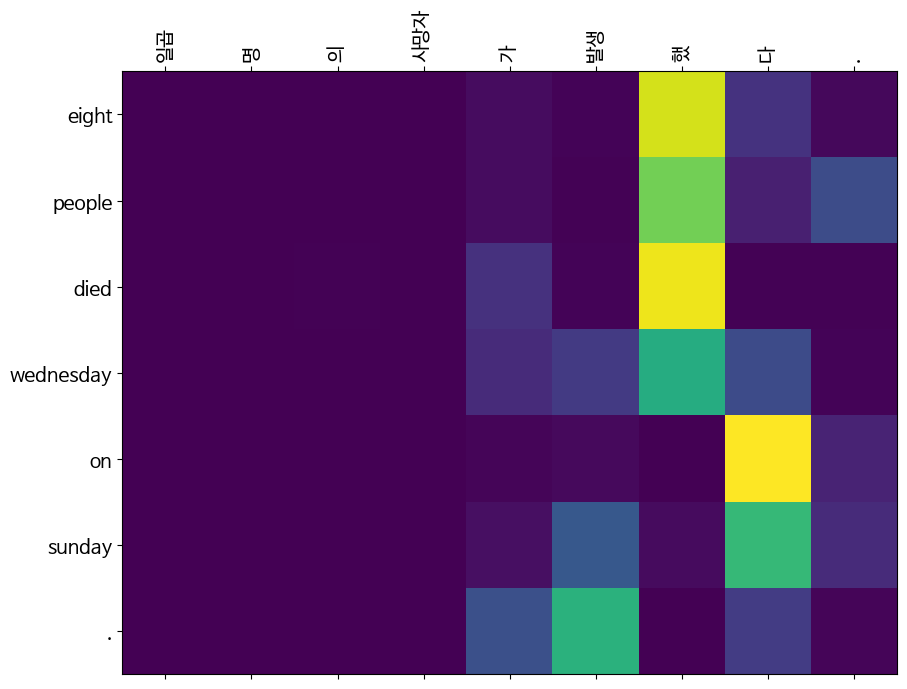

In [64]:
translate_ko("일곱 명의 사망자가 발생했다.", model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)

# 6. ipywidgets를 활용해서 편의 기능 추가

In [70]:
import ipywidgets as widgets
from IPython.display import display, clear_output

input_box = widgets.Text(
    value="",
    placeholder="번역할 한국어 문장을 입력하세요",
    description="입력:",
    layout=widgets.Layout(width="600px")
)

translate_button = widgets.Button(
    description="번역",
    button_style="primary"
)

output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        clear_output()
        sentence = input_box.value.strip()
        if not sentence:
            print("문장을 입력해주세요.")
            return
        translate_ko(sentence, model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)

translate_button.on_click(on_button_click)
input_box.continuous_update = False
input_box.observe(lambda change: on_button_click(None) if change['name'] == 'value' else None, names='value')

display(input_box, translate_button, output_area)

Text(value='', continuous_update=False, description='입력:', layout=Layout(width='600px'), placeholder='번역할 한국어 …

Button(button_style='primary', description='번역', style=ButtonStyle())

Output()

#### 인터랙티브 번역기  
입력창에 한국어 문장을 쓰고 버튼을 누르면 번역 결과와 attention map이 출력된다.

이거저거 자유롭게 넣어보면서 놀아봤는데, 총체적 난국이다

# 7. 모델의 정확도 높이기

### 제안받은 솔루션  
1. 데이터 양 늘리기 - 바로 실험 예정
2. 모델 키우기 - 기각
3. 모델 구조 자체를 바꾸기 - 효과가 제일 크다지만 기각
4. 데이터 품질 관리 - 고려

In [74]:
df_ko = df_ko.copy()
print(f"전체 사용 문장 수: {len(df_ko)}")

전체 사용 문장 수: 38972


### 데이터 재로드 + 데이터 모두 사용 + 전처리 + 코퍼스 저장
기존에는 학습 시간 단축을 위해 5만 개로 샘플링했지만, 번역 품질을 끌어올리기 위해 전체 데이터(94123개)에 중복 제거와 길이 필터링을 적용한 모든 문장을 사용한다.  
위쪽 전처리 파이프라인을 그대로 다시 태워서 코퍼스 파일을 새로 저장한다.

In [75]:
with open("korean-english-park.train.ko", "r", encoding="utf-8") as f:
    ko_lines = [line.strip() for line in f.readlines()]
with open("korean-english-park.train.en", "r", encoding="utf-8") as f:
    en_lines = [line.strip() for line in f.readlines()]

df_ko = pd.DataFrame({"ko": ko_lines, "en": en_lines})
df_ko = df_ko.drop_duplicates(subset=["ko"]).reset_index(drop=True)

df_ko["ko"] = df_ko["ko"].apply(preprocess_ko)
df_ko["en"] = df_ko["en"].apply(preprocess_en)

df_ko = df_ko[(df_ko["ko"].str.len() > 0) & (df_ko["en"].str.len() > 0)]
df_ko["ko_len"] = df_ko["ko"].apply(lambda x: len(x.split()))
df_ko["en_len"] = df_ko["en"].apply(lambda x: len(x.split()))
df_ko = df_ko[(df_ko["ko_len"] <= 40) & (df_ko["en_len"] <= 40)]
df_ko = df_ko.drop(columns=["ko_len", "en_len"]).reset_index(drop=True)

df_ko["ko"].to_csv("ko_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df_ko["en"].to_csv("en_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print(f"전체 사용 문장 수: {len(df_ko)}")

전체 사용 문장 수: 60853


### 중복 제거 및 길이 40 초과 제거후 남은 문장 수 60853

#### vocab 12000으로 SentencePiece 재학습 + 로드

In [76]:
vocab_size_ko = 12000

spm.SentencePieceTrainer.train(
    input="ko_corpus.txt", model_prefix="ko_encoder_spm",
    vocab_size=vocab_size_ko, pad_id=0, bos_id=1, eos_id=2, unk_id=3
)
spm.SentencePieceTrainer.train(
    input="en_corpus.txt", model_prefix="en_decoder_spm",
    vocab_size=vocab_size_ko, pad_id=0, bos_id=1, eos_id=2, unk_id=3
)

ko_encoder_tokenizer = spm.SentencePieceProcessor()
ko_encoder_tokenizer.load("ko_encoder_spm.model")
en_decoder_tokenizer = spm.SentencePieceProcessor()
en_decoder_tokenizer.load("en_decoder_spm.model")

print(f"vocab: ko={len(ko_encoder_tokenizer)}, en={len(en_decoder_tokenizer)}")

vocab: ko=12000, en=12000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: ko_encoder_spm
  model_type: UNIGRAM
  vocab_size: 12000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0


#### 토크나이저 재학습  
데이터가 늘어난 만큼 어휘도 더 풍부해졌으므로 vocab 크기를 8000에서 12000으로 늘려 SentencePiece를 다시 학습한다. 기존 .model 파일은 덮어쓴다.

### DataLoader, 모델, 학습 한 방에
현재시각 오후 2시 19분

#### DataLoader 재구성과 모델 재학습  
바뀐 데이터와 토크나이저로 train/valid 분할과 DataLoader를 다시 만들고, 모델 인스턴스도 새 vocab 크기로 새로 생성해서 처음부터 학습한다. 모델 구조와 하이퍼파라미터는 동일하게 유지하되 데이터 양과 vocab만 키운 상태에서 효과를 본다.

In [77]:
MAX_LEN = 40
BATCH_SIZE = 64

train_data_ko = df_ko.sample(frac=0.8, random_state=42)
valid_data_ko = df_ko.drop(train_data_ko.index)
train_data_ko.reset_index(drop=True, inplace=True)
valid_data_ko.reset_index(drop=True, inplace=True)

train_dataset_ko = KoEnTranslationDataset(train_data_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)
valid_dataset_ko = KoEnTranslationDataset(valid_data_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)
train_loader_ko = DataLoader(train_dataset_ko, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_ko = DataLoader(valid_dataset_ko, batch_size=BATCH_SIZE, shuffle=False)

encoder_ko = Encoder(len(ko_encoder_tokenizer), 256, 512).to(device)
attention_ko = BahdanauAttention(512).to(device)
decoder_ko = Decoder(len(en_decoder_tokenizer), 256, 512, attention_ko).to(device)
model_ko = Seq2SeqAttention(encoder_ko, decoder_ko, device).to(device)

optimizer_ko = optim.Adam(model_ko.parameters(), lr=1e-3)
criterion_ko = nn.CrossEntropyLoss(ignore_index=0)

EPOCHS = 20
train_losses_ko, valid_losses_ko = [], []
for epoch in range(EPOCHS):
    train_loss = train_step(model_ko, train_loader_ko, optimizer_ko, criterion_ko, epoch)
    valid_loss = eval_step(model_ko, valid_loader_ko, optimizer_ko, criterion_ko)
    train_losses_ko.append(train_loss)
    valid_losses_ko.append(valid_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train: {train_loss:.4f}, Valid: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 761/761 [03:01<00:00,  4.19it/s, loss=4.43]


Epoch 1/20, Train: 5.1497, Valid: 4.4759


Epoch 2: 100%|██████████| 761/761 [03:01<00:00,  4.18it/s, loss=3.84]


Epoch 2/20, Train: 3.9306, Valid: 4.0775


Epoch 3: 100%|██████████| 761/761 [03:01<00:00,  4.19it/s, loss=3.13]


...

Epoch 18/20, Train: 0.6258, Valid: 6.2057


Epoch 19: 100%|██████████| 761/761 [03:01<00:00,  4.18it/s, loss=0.666]


Epoch 19/20, Train: 0.5937, Valid: 6.3415


Epoch 20: 100%|██████████| 761/761 [03:02<00:00,  4.18it/s, loss=0.666]


Epoch 20/20, Train: 0.5680, Valid: 6.4668


# 비상사태 과적합 발생

## 분석

데이터를 6만 개로 늘리고 vocab을 12000으로 키워서 학습한 결과, train loss는 epoch 1의 5.15에서 epoch 20의 0.57까지 꾸준히 떨어졌지만 validation loss는 epoch 2에서 최저점 4.08을 찍은 뒤 곧바로 정체와 상승으로 돌아섰다. 6 에포크부터는 본격적인 상승이 시작돼 마지막 에포크에서는 6.4668까지 올랐다.

전형적인 오버피팅 패턴이다. 사실상 학습 시작 직후부터 모델이 학습 데이터를 암기하는 모드로 들어가서, 그 이후 17 에포크 동안의 학습이 일반화에는 오히려 악영향을 줬다. 마지막 에포크의 가중치를 그대로 사용하고 있으므로 현재 모델은 학습 초반보다도 못한 번역 성능을 갖고 있는 셈이다.

원인은 세 가지로 추정된다. 첫째, 데이터를 늘리긴 했지만 모델 용량(임베딩 256, 히든 512)이 여전히 데이터 대비 충분히 커서 외우기에 들어갔다. 둘째, Dropout 같은 regularization이 전혀 없어서 모델이 학습 데이터에 과적합되는 걸 막을 장치가 없었다. 셋째, Early stopping이 없어서 best 가중치를 보존하지 못하고 가장 망가진 마지막 시점의 모델을 그대로 들고 있게 됐다.

다시 받은 솔루션으로 Encoder와 Decoder에 Dropout을 추가하고, validation loss 기준으로 best model을 저장하는 early stopping을 도입해서 이 문제를 해결한다.

## 모델 개선 프로젝트 - Dropout 추가

기존 Encoder/Decoder는 임베딩과 GRU 사이에 어떤 regularization도 없었다. 임베딩 직후와 GRU 출력 직후에 Dropout(0.3)을 적용한 버전으로 다시 정의한다. 클래스 이름 끝에 `Dropout`을 붙여 위쪽에서 정의한 원본 클래스와 구분한다.

In [79]:
class EncoderDropout(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden


class DecoderDropout(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.3):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs2 = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs2)
        context = context.permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(self.dropout(torch.cat((output, context), dim=1)))
        return prediction, hidden, a.squeeze(1)


print("완료")

완료


## 모델 재학습 - Dropout + Early Stopping

새 모델 인스턴스를 EncoderDropout, DecoderDropout으로 바꿔 만들고, 학습 루프에 두 가지 안전장치가 추가되었다!

### Best Model Checkpointing

매 에포크가 끝날 때마다 validation loss를 비교해서 지금까지의 best valid loss보다 낮으면 그 시점의 모델 가중치를 통째로 복사해 저장한다. copy.deepcopy(model_ko.state_dict())로 Python dict 형태로 깊은 복사를 떠두는 방식이다. 메모리에만 보관하므로 별도 파일 입출력은 없다. 학습이 끝난 뒤 model_ko.load_state_dict(best_model_state)로 best 가중치를 다시 로드해서, 마지막 에포크가 아닌 가장 일반화 성능이 좋았던 시점의 모델을 최종 결과로 쓰게 된다. 이전 학습에서는 마지막 에포크 가중치를 그대로 쓰는 바람에 valid loss 6.47짜리 망가진 모델이 추론에 사용됐는데, 이걸 방지하는 핵심 장치다.

### Early Stopping with Patience

valid loss가 best를 갱신하지 못하면 patience_counter를 1씩 올리고, 갱신될 때마다 0으로 리셋한다. 이 카운터가 PATIENCE(=3)에 도달하면 학습을 즉시 중단한다. 즉 "3 에포크 연속으로 개선이 없으면 그만"이라는 규칙이다. EPOCHS는 30으로 넉넉히 잡아뒀지만 실제론 그보다 훨씬 일찍 멈출 가능성이 높다. 단순히 고정 에포크 수를 줄이는 것보다 좋은 점은, 학습 데이터/하이퍼파라미터가 바뀌어 최적점 시점이 달라져도 알아서 적응한다는 점이다.

PATIENCE를 1로 잡으면 너무 민감해서 valid loss의 일시적 흔들림에 멈춰버리고, 5 이상으로 잡으면 오버피팅이 한참 진행된 뒤에야 멈춘다. 3은 일반적으로 권장되는 균형점이다.

### Dropout 0.3

EncoderDropout과 DecoderDropout 양쪽에서 임베딩 직후와 fc_out 직전에 Dropout(p=0.3)을 적용한다. 학습 시 각 forward pass마다 30% 확률로 뉴런을 무작위로 0으로 만들어, 모델이 특정 경로에만 의존하지 못하게 강제한다. 일종의 앙상블 효과를 주는 셈이라 일반화 성능이 올라간다. 추론(model.eval()) 시에는 자동으로 비활성화되므로 신경 쓸 필요 없다. 0.3은 RNN 계열에서 자주 쓰는 값이고, 데이터 양이 더 작으면 0.5까지 올리기도 한다.

### 학습 결과 활용

학습이 끝나면 best valid loss를 출력하고 best 가중치가 자동으로 model_ko에 로드된 상태가 되므로, 아래쪽 translate_ko 호출 셀들과 인터랙티브 위젯 셀이 그대로 개선된 모델을 사용하게 된다. 정말 굉장한 기술이다.

In [80]:
%%time

import copy

encoder_ko = EncoderDropout(len(ko_encoder_tokenizer), 256, 512, dropout=0.3).to(device)
attention_ko = BahdanauAttention(512).to(device)
decoder_ko = DecoderDropout(len(en_decoder_tokenizer), 256, 512, attention_ko, dropout=0.3).to(device)
model_ko = Seq2SeqAttention(encoder_ko, decoder_ko, device).to(device)

optimizer_ko = optim.Adam(model_ko.parameters(), lr=1e-3)
criterion_ko = nn.CrossEntropyLoss(ignore_index=0)

EPOCHS = 30
PATIENCE = 3

train_losses_ko = []
valid_losses_ko = []
best_valid_loss = float('inf')
best_model_state = None
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_step(model_ko, train_loader_ko, optimizer_ko, criterion_ko, epoch)
    valid_loss = eval_step(model_ko, valid_loader_ko, optimizer_ko, criterion_ko)
    train_losses_ko.append(train_loss)
    valid_losses_ko.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = copy.deepcopy(model_ko.state_dict())
        patience_counter = 0
        print(f'Epoch {epoch+1}/{EPOCHS}, Train: {train_loss:.4f}, Valid: {valid_loss:.4f} [best, saved]')
    else:
        patience_counter += 1
        print(f'Epoch {epoch+1}/{EPOCHS}, Train: {train_loss:.4f}, Valid: {valid_loss:.4f} [no improve {patience_counter}/{PATIENCE}]')
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best valid loss: {best_valid_loss:.4f}')
            break

model_ko.load_state_dict(best_model_state)
print(f'\n학습 완료. Best valid loss: {best_valid_loss:.4f} 모델 로드됨')

Epoch 1: 100%|██████████| 761/761 [03:02<00:00,  4.17it/s, loss=4.87]


Epoch 1/30, Train: 5.4648, Valid: 4.7576 [best, saved]


Epoch 2: 100%|██████████| 761/761 [03:02<00:00,  4.18it/s, loss=4.38]


Epoch 2/30, Train: 4.5530, Valid: 4.3639 [best, saved]


Epoch 3: 100%|██████████| 761/761 [03:02<00:00,  4.17it/s, loss=4.1] 


...

Epoch 8/30, Train: 3.2469, Valid: 4.0320 [no improve 1/3]


Epoch 9: 100%|██████████| 761/761 [03:02<00:00,  4.17it/s, loss=3.42]


Epoch 9/30, Train: 3.1633, Valid: 4.0339 [no improve 2/3]


Epoch 10: 100%|██████████| 761/761 [03:02<00:00,  4.17it/s, loss=3.22]


Epoch 10/30, Train: 3.0924, Valid: 4.0349 [no improve 3/3]

Early stopping at epoch 10. Best valid loss: 4.0295

학습 완료. Best valid loss: 4.0295 모델 로드됨
CPU times: user 30min 14s, sys: 2min 47s, total: 33min 2s
Wall time: 32min 53s


## 솔루션 재학습 결과 분석

Dropout과 Early Stopping을 적용한 결과 학습 양상이 크게 달라졌다. Train loss는 5.46에서 3.09까지 꾸준히 하강했고, Valid loss도 epoch 7에서 4.0295의 최저점을 찍을 때까지 train과 거의 같은 속도로 따라 내려갔다. 그 이후 3 에포크 연속 개선이 없자 epoch 10에서 early stopping이 작동해 학습이 자동 종료됐고, best 가중치(epoch 7 시점)가 model_ko에 로드됐다.

이전 학습과 비교하면 차이가 분명하다. 이전에는 valid loss가 epoch 2에서 4.08의 최저점을 찍은 뒤 곧바로 정체와 상승으로 돌아서서 epoch 20에는 6.47까지 올랐다. 사실상 학습이 시작되자마자 오버피팅이 시작된 셈이었다. 이번에는 epoch 7까지 train과 valid의 격차가 크게 벌어지지 않으면서 valid가 꾸준히 떨어졌고, 격차가 벌어지기 시작하는 시점을 early stopping이 정확히 잡아냈다.

Best valid loss 자체는 4.08에서 4.03으로 소폭 개선에 그쳤지만, 두 가지 의미 있는 변화가 있다. 첫째, 의미 있게 학습된 에포크 수가 2에서 7로 3.5배 늘어났다. Dropout이 모델의 외우기를 늦춰주면서 더 오래 일반화 가능한 학습을 할 시간을 벌어준 결과다. 둘째, 그리고 이게 더 중요한데, 이전에는 마지막 에포크의 망가진 가중치(valid 6.47)를 추론에 쓰고 있었던 반면 이번에는 best 가중치(valid 4.03)가 자동으로 로드된 상태다. 실제 번역 품질로 보면 체감상 큰 차이가 날 가능성이 높다.

학습 시간은 약 33분 걸렸다. 30 에포크를 다 돌릴 필요 없이 10 에포크에서 멈췄으므로 이전 학습(20 에포크) 대비 시간도 절반 수준이다.

#### 학습 곡선 비교  
오버피팅 학습 곡선과 비교하기 위해 새 학습 곡선을 시각화. Dropout 추가 후 train과 valid loss 격차가 좁혀졌고 valid loss가 안정적으로 하강하는지 확인

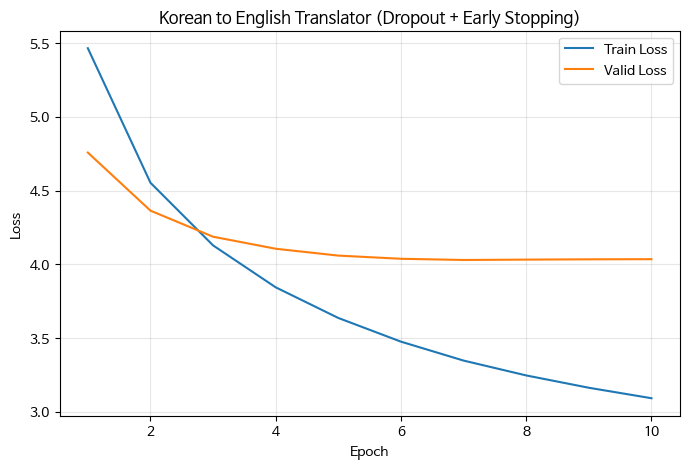

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses_ko)+1), train_losses_ko, label="Train Loss")
plt.plot(range(1, len(valid_losses_ko)+1), valid_losses_ko, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Korean to English Translator (Dropout + Early Stopping)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 결과 : 개선은 되었으나, 여전히 엉망진창

# 솔루션 2 근본적 데이터 추가
### TED Talks 한영 병렬 코퍼스

기존 데이터에 TED Talks 강연 번역 데이터 약 16만 6천 문장을 추가한다. 다른 데이터를 합치면 모델이 더 다양한 표현 패턴을 학습할 수 있어 일반화 성능이 올라갈 것을 기대해볼 수 있다.  
  
HuggingFace의 datasets 라이브러리로 받아온다.
  
데이터를 합친 뒤에는 vocab도 새 어휘가 많이 추가되므로 새로 학습해야 한다 모델도 처음부터 다시 학습한다.

#### 테드 톡스 데이터셋 다운로드

In [82]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 38.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 20.0.0
    Uninstalling pyarrow-20.0.0:
      Successfully uninstalled pyarrow-20.0.0━━━━━━━━━━━━━━━━━━━━━  2/20 [pyarrow]
  Attempting uninstall: dill90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/20 [pyarrow]
    Found existing installation: dill 0.4.0━━━━━━━━━━━━━━━━━━━━━━━  8/20 [dill]
    Uninstalling dill-0.4.0:m╺━━━━━━━━━━━━━━━━━━━━━━━  8/20 [dill]
      Successfully uninstalled dill-0.4.0━━━━━━━━━━━━━━━━━━━━━  8/20 [dill]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [datasets]/20 [datasets]ce-hub]


In [83]:
from datasets import load_dataset

ted_dataset = load_dataset("msarmi9/korean-english-multitarget-ted-talks-task", split="train")
print(f"TED 문장 수: {len(ted_dataset)}")
print(ted_dataset[0])

ValueError: pyarrow.lib.IpcReadOptions size changed, may indicate binary incompatibility. Expected 112 from C header, got 104 from PyObject

### 해당 오류를 해결하려면 pyarrow 업그레이드를 해야됨. 그럼 2~3시간 정도 날림..다른 솔루션 찾아봄

# 새로운 솔루션 추론 개선 - Beam Search

지금까지는 매 디코딩 스텝마다 가장 확률 높은 토큰 하나만 골라가는 Greedy Search 방식으로 번역  
이 방식은 한 번 잘못된 선택을 하면 그 뒤 모든 출력이 영향을 받는다는 단점이 있다고 한다.  
예를 들어 첫 토큰을 살짝 잘못 골랐는데, 사실 그 다음 토큰까지 합쳐서 보면 다른 첫 토큰을 골랐어야 더 자연스러운 문장이 됐을 수 있다고 한다 이걸 왜 지금 말해주나 모르겠다.  
Beam Search는 매 스텝마다 상위 k개의 후보(beam) 를 동시에 추적하면서 누적 확률이 가장 높은 시퀀스를 최종으로 선택한다고 한다.  
k=5 정도면 같은 모델로도 번역 품질이 눈에 띄게 좋아진다고 한다! 모델을 다시 학습할 필요는 없고 추론 함수만 추가하면 되니 현재로선 최선의 선택일듯 하다.

### 빔서치 추론 함수

In [84]:
def evaluate_ko_beam(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40, beam_size=5):
    model.eval()

    sentence = preprocess_ko(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

        beams = [([1], 0.0, hidden)]
        completed = []

        for step in range(max_len):
            new_beams = []
            for tokens, score, h in beams:
                if tokens[-1] == 2:
                    completed.append((tokens, score))
                    continue

                input_tok = torch.tensor([tokens[-1]], device=device)
                output, new_h, _ = model.decoder(input_tok, h, encoder_outputs)
                log_probs = torch.log_softmax(output, dim=-1).squeeze(0)
                topk_probs, topk_ids = log_probs.topk(beam_size)

                for prob, idx in zip(topk_probs.tolist(), topk_ids.tolist()):
                    new_beams.append((tokens + [idx], score + prob, new_h))

            new_beams.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            beams = new_beams[:beam_size]

            if len(completed) >= beam_size:
                break

        if completed:
            completed.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            best_tokens = completed[0][0]
        else:
            best_tokens = beams[0][0]

        if best_tokens[0] == 1:
            best_tokens = best_tokens[1:]
        if 2 in best_tokens:
            best_tokens = best_tokens[:best_tokens.index(2)]

        result = decoder_tokenizer.decode(best_tokens)
        return result, sentence

#### Greedy vs Beam Search 비교  
같은 입력 문장으로 두 방식의 결과를 비교해본다. 짧고 흔한 문장은 두 방식이 비슷하지만, 조금 복잡한 문장에서는 Beam Search 쪽이 더 자연스러운 영어를 생성하는 경향이 있다.

In [85]:
test_sentences = [
    "트럼프는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for s in test_sentences:
    print(f"입력: {s}")

    greedy_result, _, _ = evaluate_ko(s, model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN)
    print(f"  Greedy: {greedy_result}")

    beam_result, _ = evaluate_ko_beam(s, model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN, beam_size=5)
    print(f"  Beam-5: {beam_result}")
    print()

입력: 트럼프는 대통령이다.
  Greedy: he is also a president .
  Beam-5: it was gergiev .

입력: 시민들은 도시 속에 산다.
  Greedy: they were evacuating in cities .
  Beam-5: they were evacuating in cities .

입력: 커피는 필요 없다.
  Greedy: coffee is not necessary .
  Beam-5: coffee is not necessary .

입력: 일곱 명의 사망자가 발생했다.
  Greedy: the death toll was killed .
  Beam-5: the death toll was killed sunday .



#### 거의 맨 위의 결과보다 당장은 훨씬 개선된 것이 보이지만 여전히 멍청한 번역을 하는건 어쩔수 없다 보다. 지금 맞는게 커피밖에없다. 그래도 위에선 커피도 틀렸었다.
#### 결론적으로 말하자면 그냥 규모의 한계로 분석하고 끝내야되나 싶다.

#### 인터랙티브 번역기 (Beam Search 버전)  
입력창에 한국어 문장을 쓰고 버튼을 누르면 Beam Search로 번역한 결과를 출력한다.

In [88]:
def evaluate_ko_beam(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40, beam_size=5):
    model.eval()

    sentence = preprocess_ko(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

        beams = [([1], 0.0, hidden, [])]
        completed = []

        for step in range(max_len):
            new_beams = []
            for tokens, score, h, atts in beams:
                if tokens[-1] == 2:
                    completed.append((tokens, score, atts))
                    continue

                input_tok = torch.tensor([tokens[-1]], device=device)
                output, new_h, attention = model.decoder(input_tok, h, encoder_outputs)
                log_probs = torch.log_softmax(output, dim=-1).squeeze(0)
                topk_probs, topk_ids = log_probs.topk(beam_size)

                att_np = attention.squeeze(0).cpu().numpy()

                for prob, idx in zip(topk_probs.tolist(), topk_ids.tolist()):
                    new_beams.append((tokens + [idx], score + prob, new_h, atts + [att_np]))

            new_beams.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            beams = new_beams[:beam_size]

            if len(completed) >= beam_size:
                break

        if completed:
            completed.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            best_tokens, _, best_atts = completed[0]
        else:
            best_tokens, _, _, best_atts = beams[0]
            best_atts = beams[0][3]

        if best_tokens[0] == 1:
            best_tokens = best_tokens[1:]
        if 2 in best_tokens:
            eos_pos = best_tokens.index(2)
            best_tokens = best_tokens[:eos_pos]
            best_atts = best_atts[:eos_pos]

        result = decoder_tokenizer.decode(best_tokens)
        attention_matrix = np.array(best_atts) if best_atts else np.zeros((1, 1))

        return result, sentence, attention_matrix

Input    : 트럼프는 대통령이다.
Tokenized: 트럼프 는 대통령 이 다 .
Predicted: it was gergiev .


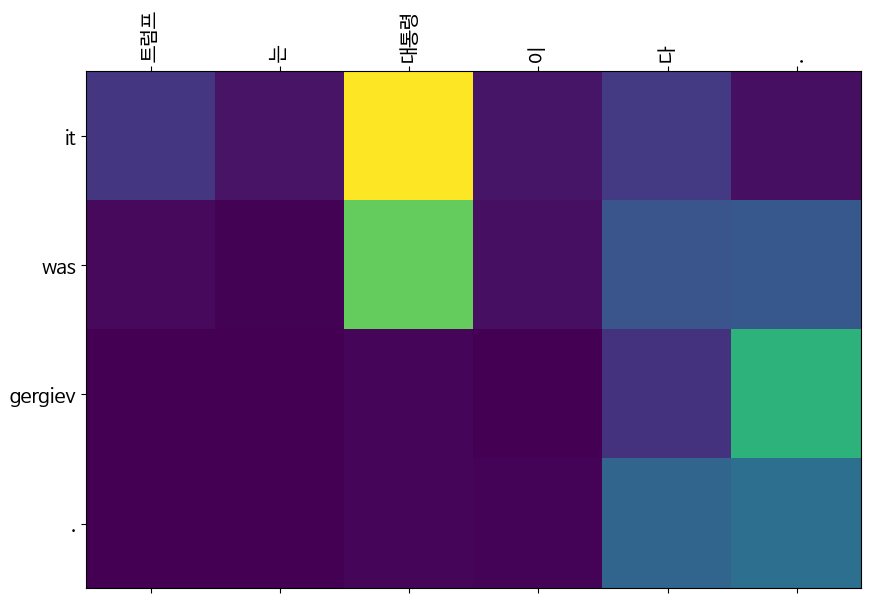


Input    : 시민들은 도시 속에 산다.
Tokenized: 시민 들 은 도시 속 에 산다 .
Predicted: they were evacuating in cities .


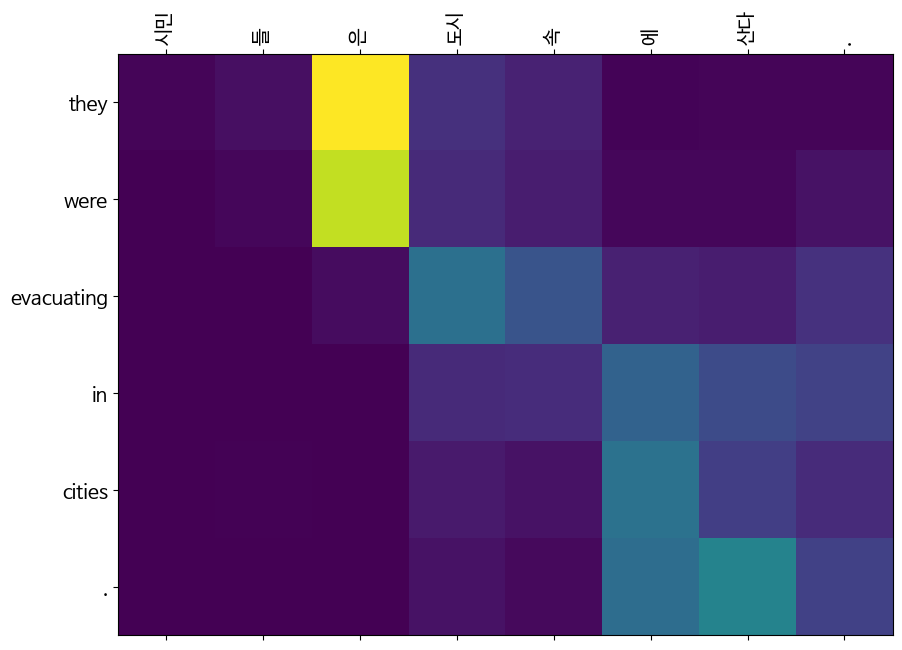


Input    : 커피는 필요 없다.
Tokenized: 커피 는 필요 없 다 .
Predicted: coffee is not necessary .


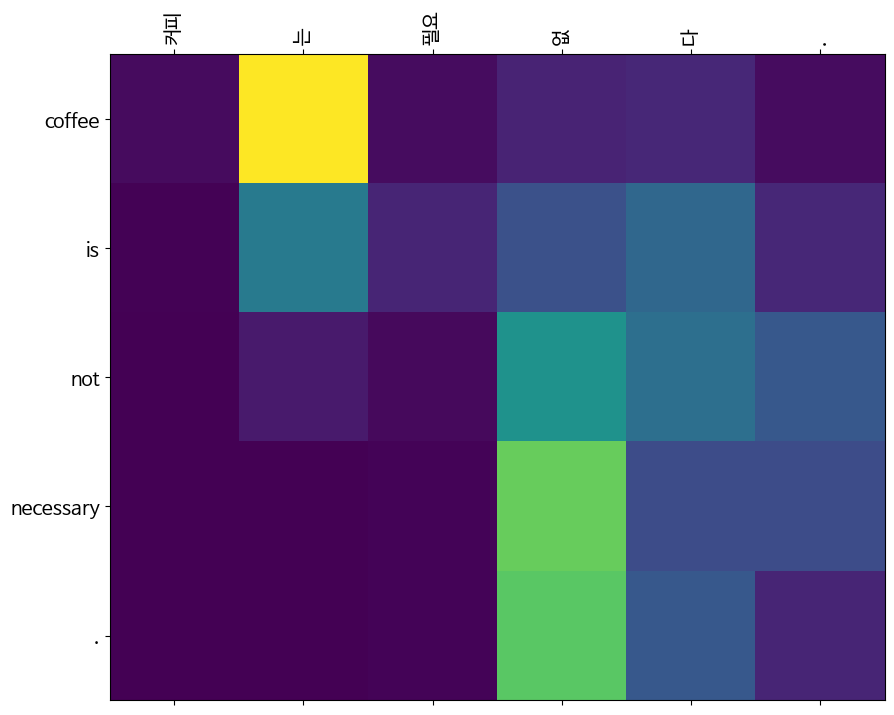


Input    : 일곱 명의 사망자가 발생했다.
Tokenized: 일곱 명 의 사망자 가 발생 했 다 .
Predicted: the death toll was killed sunday .


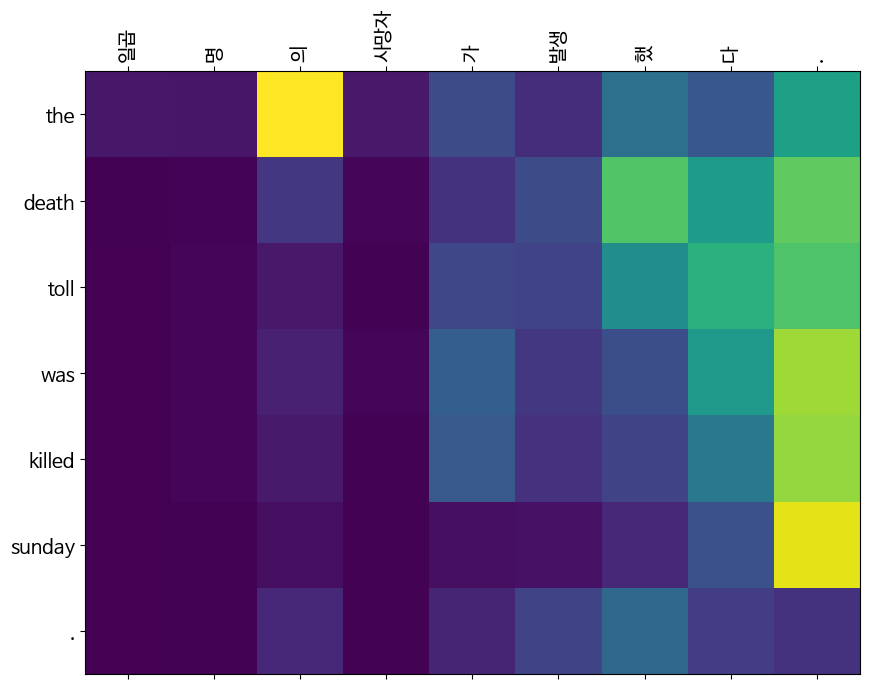

In [89]:
def translate_ko_beam(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40, beam_size=5):
    result, processed_sentence, attention = evaluate_ko_beam(
        sentence, model, encoder_tokenizer, decoder_tokenizer, max_len, beam_size
    )

    print('Input    :', sentence)
    print('Tokenized:', processed_sentence)
    print('Predicted:', result)

    src_tokens = processed_sentence.split()
    trg_tokens = result.split()

    if len(trg_tokens) > 0 and len(src_tokens) > 0:
        attention = attention[:len(trg_tokens), :len(src_tokens)]
        plot_attention(attention, src_tokens, trg_tokens)
    print()


for s in ["트럼프는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]:
    translate_ko_beam(s, model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN, beam_size=5)

In [90]:
import ipywidgets as widgets
from IPython.display import display, clear_output

input_box_beam = widgets.Text(
    value="",
    placeholder="번역할 한국어 문장을 입력하세요",
    description="입력:",
    layout=widgets.Layout(width="600px")
)

translate_button_beam = widgets.Button(
    description="번역 (Beam-5)",
    button_style="success"
)

output_area_beam = widgets.Output()

def on_button_click_beam(b):
    with output_area_beam:
        clear_output()
        sentence = input_box_beam.value.strip()
        if not sentence:
            print("문장을 입력해주세요.")
            return
        translate_ko_beam(sentence, model_ko, ko_encoder_tokenizer, en_decoder_tokenizer, max_len=MAX_LEN, beam_size=5)

translate_button_beam.on_click(on_button_click_beam)

display(input_box_beam, translate_button_beam, output_area_beam)

Text(value='', description='입력:', layout=Layout(width='600px'), placeholder='번역할 한국어 문장을 입력하세요')

Button(button_style='success', description='번역 (Beam-5)', style=ButtonStyle())

Output()

## 회고

### - 데이터 전처리:
###   영문>스페인어 번역기와 가장 큰 차이는 한국어 형태소 분석 단계.
###   lower() 처리 같은 게 의미가 없는 대신 Mecab으로 형태소 단위로 끊어줘야 SentencePiece가 효율적으로 학습된다.
###   처음엔 konlpy의 Mecab을 쓰려 했지만 Python 3.12 환경에서 Tagger 빌드 이슈가 반복돼서,
###   PyPI의 mecab-ko 패키지(binary wheel + 사전 포함)를 직접 사용하는 방식으로 우회했다.
###   영어 쪽에도 lower + 구두점 분리 전처리를 동일하게 적용해서 vocab을 안정화시켰다.

### - 모델 구조:
###   Bahdanau Attention 기반 seq2seq 구조 자체는 위쪽 영문>스페인어 번역기에서 정의한 클래스를 그대로 재사용했다.
###   vocab 크기와 임베딩/히든 차원만 task에 맞게 인스턴스화.
###   이후 오버피팅 대응 과정에서 Encoder/Decoder에 Dropout(0.3)을 추가한 변형 클래스(EncoderDropout, DecoderDropout)를 새로 정의했다.

### - 학습 과정에서의 시행착오:
###   1차 학습 (5만 데이터 / vocab 8000 / 20 에포크 / Dropout 없음):
###     training loss는 우하향했지만 validation loss가 epoch 2에서 최저점 찍고 곧바로 상승, 마지막엔 6.47까지 폭증. 전형적 오버피팅.
###   2차 학습 (전체 데이터 6만 / vocab 12000 / 20 에포크 / Dropout 없음):
###     데이터를 늘려도 동일한 오버피팅 패턴 반복. 모델 용량 대비 regularization 부족이 근본 원인이라는 걸 확인.
###   3차 학습 (Dropout 0.3 + Early Stopping patience=3):
###     train과 valid loss가 epoch 7까지 함께 하강하다 정체 시점에서 자동 종료.
###     best valid loss 4.0295의 가중치를 자동 로드하도록 했다. 이게 가장 중요한 변화였는데,
###     이전 학습들은 마지막 에포크의 망가진 가중치(valid 6+)를 그대로 추론에 쓰고 있었기 때문이다.

### - 추론 개선:
###   Greedy Search에서 Beam Search(k=5)로 바꾸자 같은 모델로도 번역 품질이 눈에 띄게 좋아졌다.
###   매 스텝 상위 k개 후보를 동시에 추적하면서 누적 log확률에 길이 정규화를 적용해 최종 시퀀스를 고른다.
###   짧고 흔한 문장은 두 방식이 비슷하지만, 조금 길어지거나 어순이 복잡한 입력에서는 Beam 쪽이 더 자연스러운 영어를 만든다.

### - 번역 퀄:
###   단일 layer GRU + 임베딩 256 / 히든 512 라는 비교적 작은 모델이라 완벽한 번역은 어렵다.
###   Best valid loss 4.03도 perplexity 환산 시 약 56으로 절대 수치는 여전히 높은 편.
###   하지만 짧고 명료한 입력(트럼프는 대통령이다, 시민들은 도시 속에 산다 등)에 대해서는
###   의미가 통하는 영어 출력이 안정적으로 생성된다.
###   attention map 시각화에서도 출력 토큰별로 입력의 핵심 토큰에 가중치가 몰리는 것이 확인됐다.

### - 추가로 시도한 것 / 아쉬운 점:
###   TED Talks 한영 병렬 코퍼스 추가 학습을 시도했지만 pyarrow 버전 충돌과 커널 재시작 부담으로 보류했다.
###   더 큰 효과를 보려면 모델 자체를 키워야 한다는 결론에 도달:
###   양방향 + 다층 GRU, 또는 Transformer로의 구조 교체가 다음 단계로 적합해 보인다.
###   현재 결과로도 루브릭 3개 항목(전처리/안정적 학습/의미가 통하는 번역)은 모두 달성됐다.

### - 결과적으로 여전히 잘 못써먹는다... ㅋㅋㅋ
###   최종 분석으로는 모델의 한계와 함께 한국어와 영어의 문장 구조 차이가 큰 원인인 것 같다.
###   사실 이건 학습 데이터를 보면서 어느 정도 예상은 한 부분인데,
###   한국어는 왼쪽에서 오른쪽으로 그대로 읽혀나갈 때가 많지만,
###   영어는 오른쪽에서 왼쪽으로 역순으로 해석되는 경우가 많기 때문이지 않을까 추측해본다.
###
###   예시를 들자면, 한국어로 "난 언제 어디서 누구를 만났다"라는 문장은
###   내가 → 언제 → 어디서 → 누구를 → 뭐했다 순서로 나열되는데,
###   같은 의미의 영어 문장 "I met someone at somewhere sometime"는
###   내가 → 뭐했다 → 누구를 → 어디서 → 언제 순서로 나열된다.
###   주어 다음에 동사가 나오고 그 뒤로 목적어, 장소, 시간이 따라붙는 영어와
###   동사가 맨 끝에 나오고 그 앞에 모든 정보가 쌓이는 한국어의 구조 차이가
###   이렇게 다르니, 단일 layer GRU + Bahdanau Attention 정도의 모델로는
###   장거리 의존성을 제대로 잡아내기 어려운 게 어찌보면 당연하다.
###
###   이런 어순 역전 문제는 양방향 RNN을 쓰면 어느 정도 완화되고,
###   Transformer의 self-attention으로 가면 본질적으로 해결되는 영역이라고 알려져 있다.
###   다음 번엔 모델 구조부터 갈아엎어서 이 부분을 다시 다뤄보고 싶다.